# Import de bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Leitura e Limpeza dos dados

Não houve nenhuma alteração nos dados, não tem outliers e nem missing_values.
A baixo segue também a distribuição dos dados em gráficos para melhor visualização.
É muito interessante olhar a distribuição dos dados categóricos para ver um posível viez dos dados
Porém, eu não acho que há algum viez. (anotação)

---



##Leitura

In [ ]:
#Leitura do arquivo
df = pd.read_csv('Global_AI_Content_Impact_Dataset.csv', sep = ',')
#Primeiras 20 linhas
df.head(n =20)

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
6,Australia,2023,Media,68.23,6.14,6.20,53.13,53.16,Claude,Moderate,71.60,15.26
7,UK,2023,Gaming,91.27,33.87,41.67,56.26,59.93,ChatGPT,Moderate,46.98,28.51
8,Canada,2025,Education,17.02,87.77,4.59,52.45,64.72,Claude,Moderate,60.55,22.70
9,China,2025,Healthcare,25.50,18.74,15.07,40.81,64.86,Stable Diffusion,Moderate,51.07,39.97


In [ ]:
#Avaliando se há variáveis nulas e o tipo de variável de cada coluna
df.info()
#quantidade de linhas e colunas
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

(200, 12)

Não há missing values

##Quantidade de aparições das variáveis categóricas e Years

Importante ver a quantidade de aparições para análisar um possível inviesamento dos dados ou uma possível tendência

In [ ]:
# Colunas categóricas e número de aparições de cada variável
categorical_cols = ['Country','Year', 'Industry', 'Top AI Tools Used', 'Regulation Status']
categorical_counts = {}

# Criando os dicionários de contagem para cada coluna categórica
for col in categorical_cols:
    categorical_counts[col] = df[col].value_counts().to_dict()
    print(f"Contagem de valores para a coluna '{col}':")
    print(categorical_counts[col])
    print("-" * 30)

Contagem de valores para a coluna 'Country':
{'India': 24, 'France': 24, 'Japan': 22, 'China': 21, 'USA': 21, 'South Korea': 20, 'UK': 20, 'Germany': 17, 'Canada': 16, 'Australia': 15}
------------------------------
Contagem de valores para a coluna 'Year':
{2020: 47, 2025: 38, 2021: 32, 2022: 31, 2023: 29, 2024: 23}
------------------------------
Contagem de valores para a coluna 'Industry':
{'Media': 31, 'Gaming': 27, 'Retail': 21, 'Automotive': 19, 'Marketing': 19, 'Manufacturing': 18, 'Legal': 17, 'Education': 17, 'Healthcare': 17, 'Finance': 14}
------------------------------
Contagem de valores para a coluna 'Top AI Tools Used':
{'Midjourney': 37, 'Claude': 31, 'ChatGPT': 31, 'Stable Diffusion': 27, 'DALL-E': 26, 'Bard': 24, 'Synthesia': 24}
------------------------------
Contagem de valores para a coluna 'Regulation Status':
{'Moderate': 76, 'Lenient': 63, 'Strict': 61}
------------------------------


Acho interessante pensar porque há mais aparições de 2020 do que dos anos até 2025 nos dados, dado que parece ser um concensso que a AI começou a ser mais usada pós 2020 ou/e pensar pq tem mais dados de Media e Gaming. (anotação)

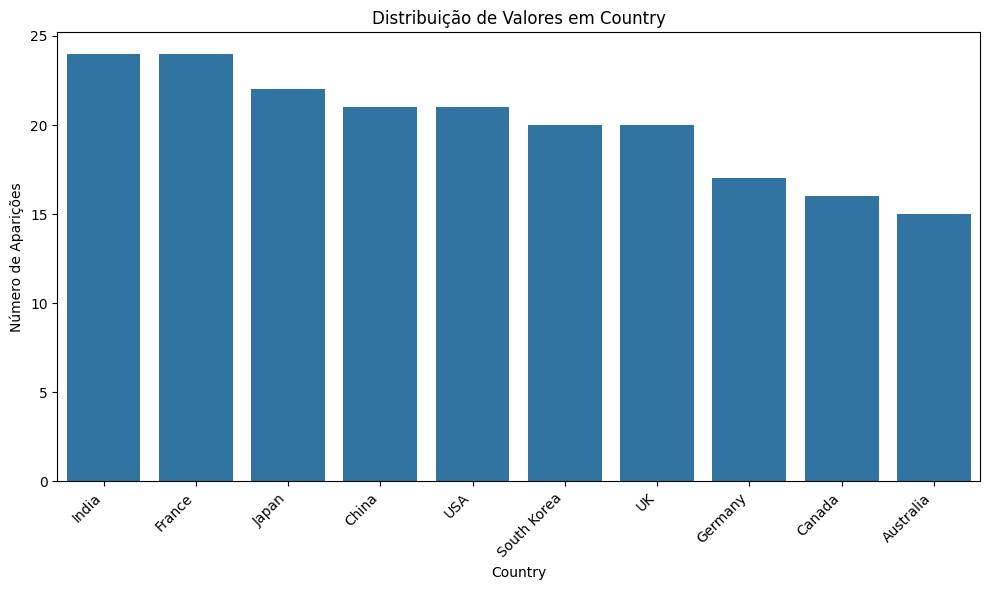

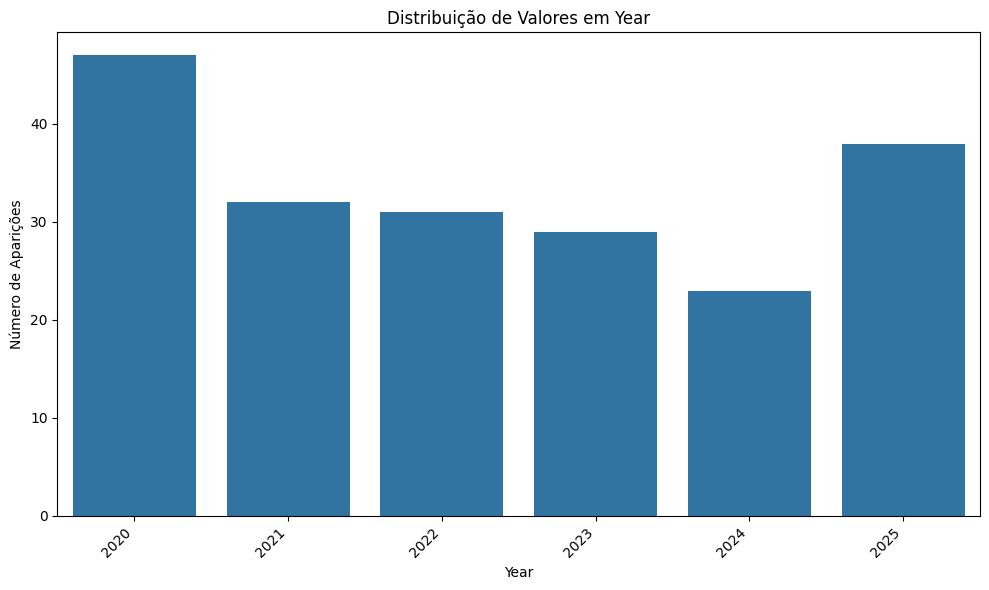

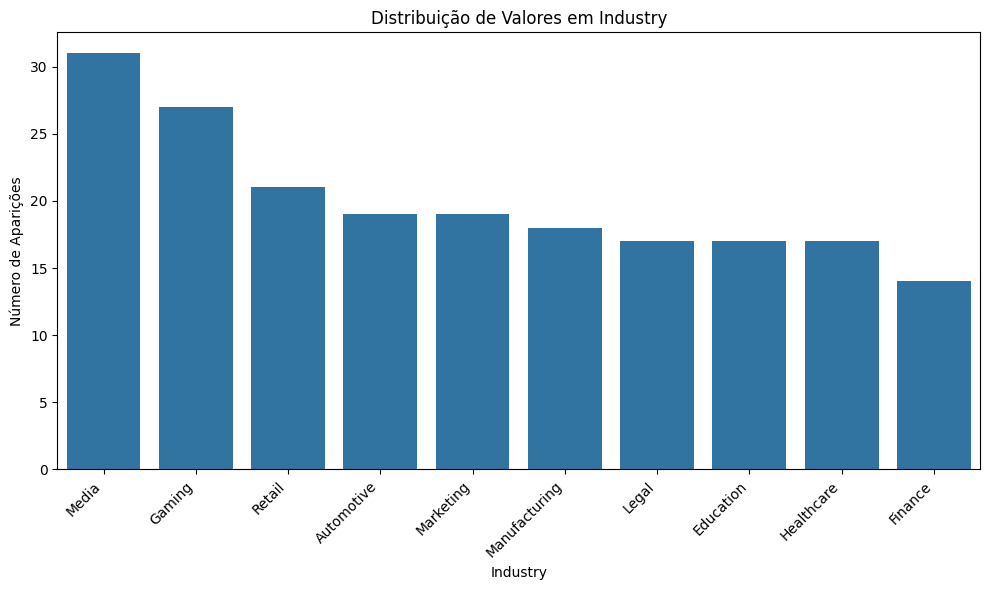

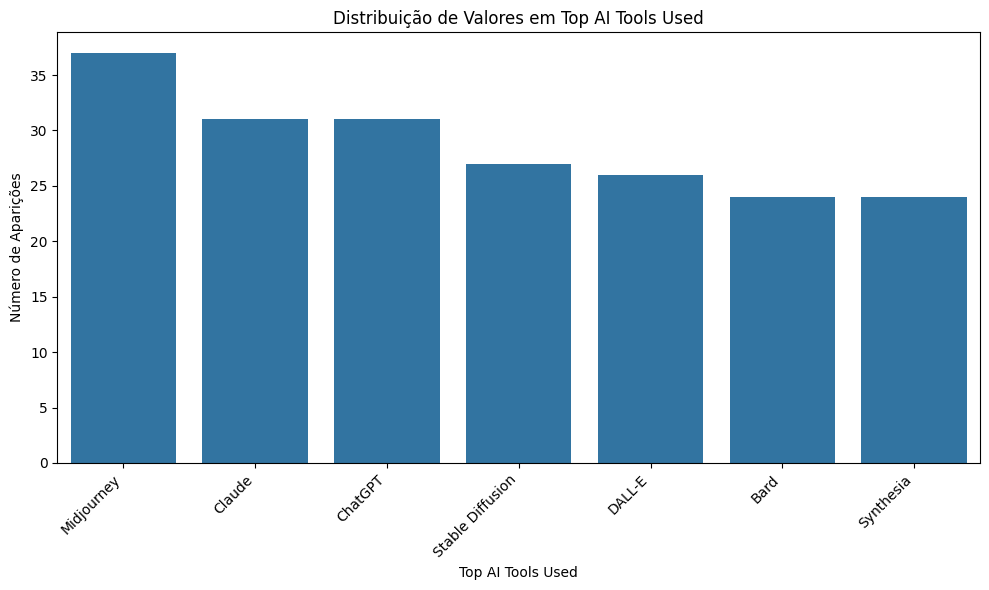

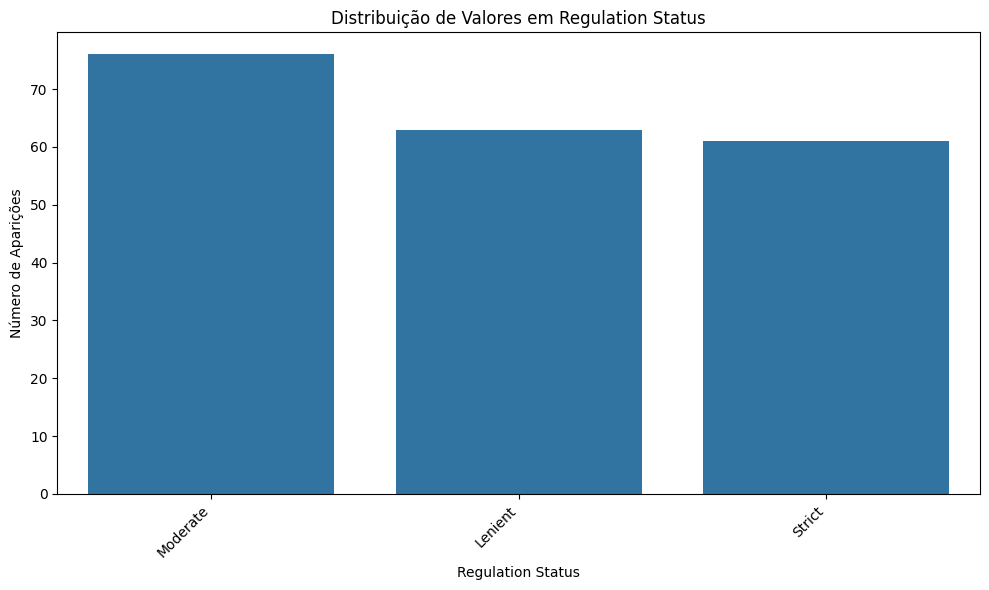

In [ ]:
# Gerando os gráficos de barras das aparições
for col, counts in categorical_counts.items():
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()))
    plt.title(f'Distribuição de Valores em {col}')
    plt.xlabel(col)
    plt.ylabel('Número de Aparições')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

##Quartis e Boxplot (Variáveis quantitativas)


Spoiler: não há outliers

In [ ]:
quantitative_cols = ['AI Adoption Rate (%)', 'AI-Generated Content Volume (TBs per year)',
                     'Job Loss Due to AI (%)', 'Revenue Increase Due to AI (%)',
                     'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)',
                     'Market Share of AI Companies (%)']
quartiles = {}

# Calculando os quartis para cada coluna quantitativa
for col in quantitative_cols:
    quartiles[col] = df[col].quantile([0.25, 0.50, 0.75]).to_dict()
    print(f"Quartis para a coluna '{col}':")
    print(quartiles[col])
    print("-" * 30)

Quartis para a coluna 'AI Adoption Rate (%)':
{0.25: 33.2225, 0.5: 53.31, 0.75: 76.22}
------------------------------
Quartis para a coluna 'AI-Generated Content Volume (TBs per year)':
{0.25: 20.3225, 0.5: 44.32, 0.75: 71.62}
------------------------------
Quartis para a coluna 'Job Loss Due to AI (%)':
{0.25: 14.995000000000001, 0.5: 25.735, 0.75: 37.417500000000004}
------------------------------
Quartis para a coluna 'Revenue Increase Due to AI (%)':
{0.25: 17.9075, 0.5: 42.1, 0.75: 58.697500000000005}
------------------------------
Quartis para a coluna 'Human-AI Collaboration Rate (%)':
{0.25: 37.77, 0.5: 54.515, 0.75: 69.4025}
------------------------------
Quartis para a coluna 'Consumer Trust in AI (%)':
{0.25: 44.755, 0.5: 59.215, 0.75: 74.88499999999999}
------------------------------
Quartis para a coluna 'Market Share of AI Companies (%)':
{0.25: 14.0525, 0.5: 27.39, 0.75: 38.432500000000005}
------------------------------


In [ ]:
#Contagem de outliers
outlier_counts = {}

for col in quantitative_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)
    print(f"A coluna '{col}' tem {outlier_counts[col]} outlier(s).")

print("\nContagem total de outliers por coluna:")
print(outlier_counts)

A coluna 'AI Adoption Rate (%)' tem 0 outlier(s).
A coluna 'AI-Generated Content Volume (TBs per year)' tem 0 outlier(s).
A coluna 'Job Loss Due to AI (%)' tem 0 outlier(s).
A coluna 'Revenue Increase Due to AI (%)' tem 0 outlier(s).
A coluna 'Human-AI Collaboration Rate (%)' tem 0 outlier(s).
A coluna 'Consumer Trust in AI (%)' tem 0 outlier(s).
A coluna 'Market Share of AI Companies (%)' tem 0 outlier(s).

Contagem total de outliers por coluna:
{'AI Adoption Rate (%)': 0, 'AI-Generated Content Volume (TBs per year)': 0, 'Job Loss Due to AI (%)': 0, 'Revenue Increase Due to AI (%)': 0, 'Human-AI Collaboration Rate (%)': 0, 'Consumer Trust in AI (%)': 0, 'Market Share of AI Companies (%)': 0}


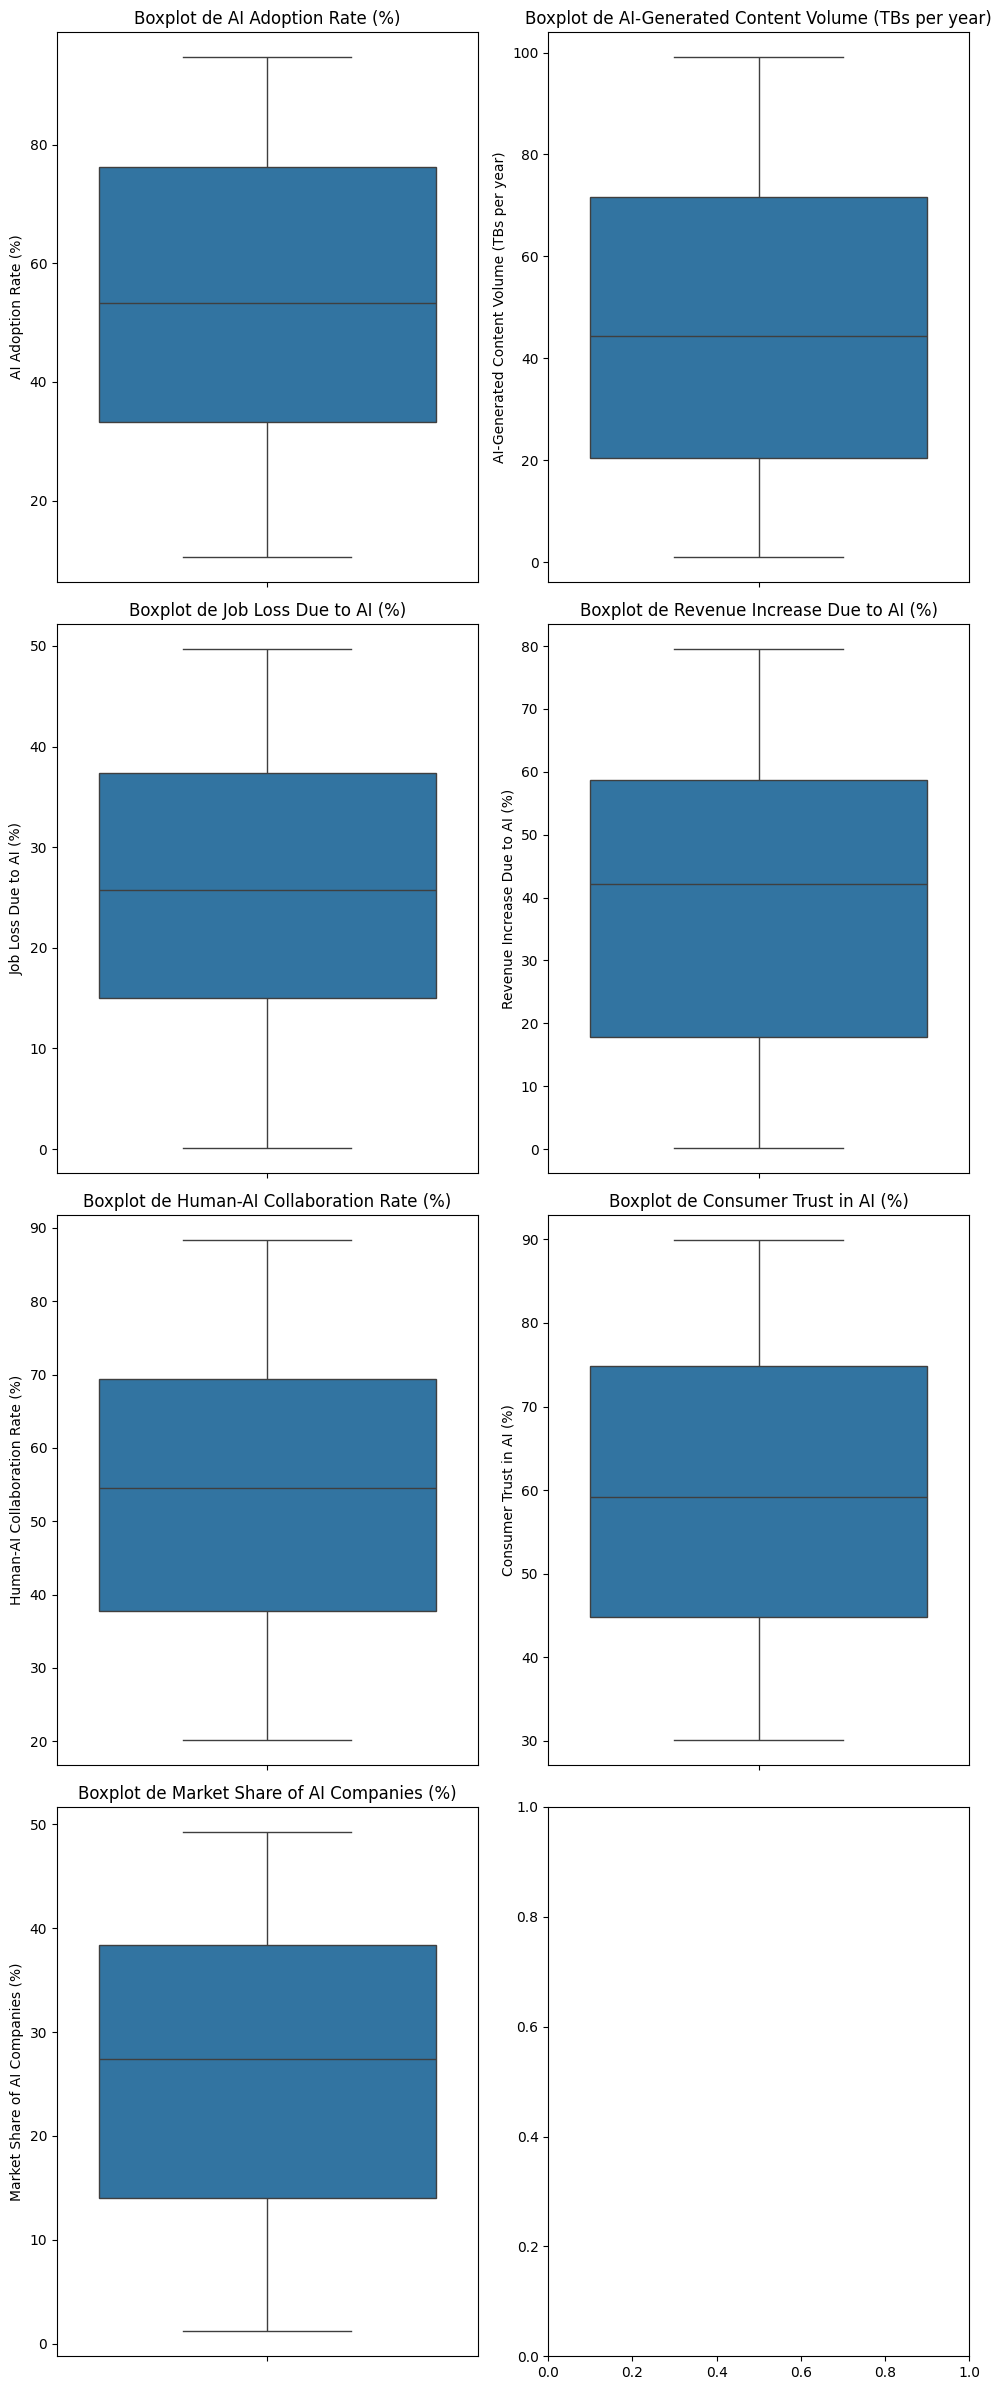

In [ ]:
num_cols = len(quantitative_cols)
num_rows = (num_cols + 1) // 2  # Calcula o número de linhas necessárias

fig, axes = plt.subplots(num_rows, 2, figsize=(10, 6 * num_rows))
axes = axes.flatten()  # Transforma a matriz de eixos em um array plano para facilitar a indexação

for i, col in enumerate(quantitative_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()